## Data Collect

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv('heart.csv')

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## EDA

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
#data shape chec
df.shape

(918, 12)

In [ ]:
# features data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
# real life may impossible values data set may  pakarna
df[["Age","RestingBP","Cholesterol","MaxHR"]].describe()

,Age,RestingBP,Cholesterol,MaxHR
count,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368
std,9.432617,18.514154,109.384145,25.460334
min,28.000000,0.000000,0.000000,60.000000
25%,47.000000,120.000000,173.250000,120.000000
50%,54.000000,130.000000,223.000000,138.000000
75%,60.000000,140.000000,267.000000,156.000000
max,77.000000,200.000000,603.000000,202.000000


In [ ]:
df[df['RestingBP'] < 90]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
314,53,M,ASY,80,0,0,Normal,141,Y,2.0,Down,0
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [ ]:
df[df['Cholesterol'] < 100]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
98,56,M,ASY,120,85,0,Normal,140,N,0.0,Up,0
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


([<matplotlib.patches.Wedge at 0x7b99f4621280>,
 [Text(-0.18359412736194164, 1.084570512414111, '1'),
  Text(0.18359448075986173, -1.0845704525914934, '0')],
 [Text(-0.1001422512883318, 0.5915839158622423, '55.34'),
  Text(0.10014244405083365, -0.5915838832317236, '44.66')])

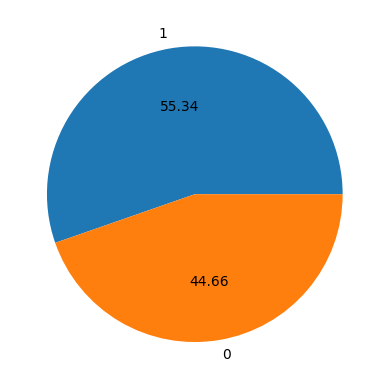

In [ ]:
#check target variable balanced
plt.pie(df['HeartDisease'].value_counts(),labels=df['HeartDisease'].value_counts().index,autopct="%0.2f")

/tmp/ipython-input-996/2626872655.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])
/tmp/ipython-input-996/2626872655.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['RestingBP'])


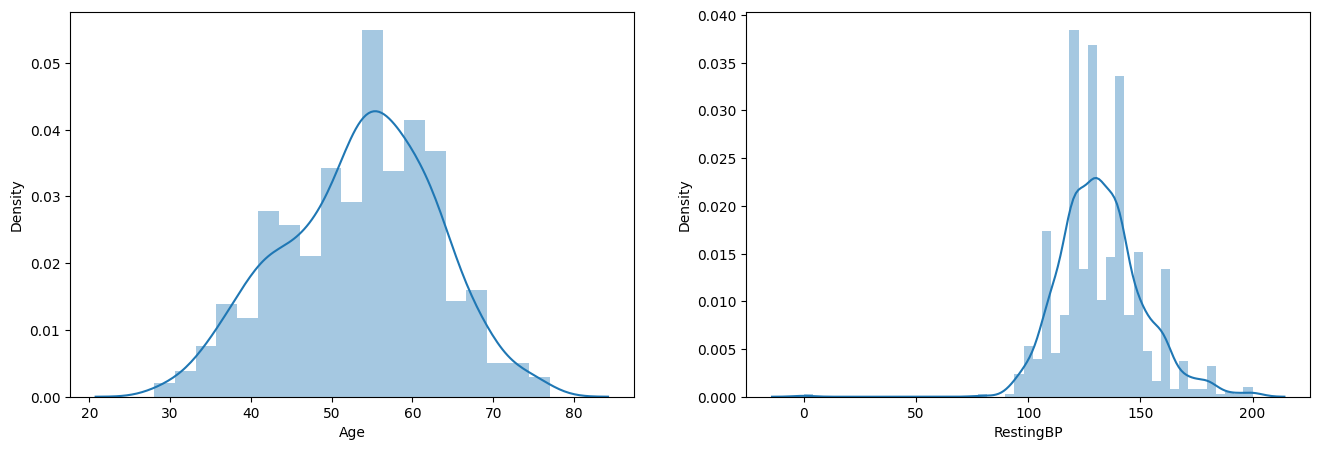

In [ ]:
# check numerical features distribution
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['Age'])

plt.subplot(1,2,2)
sns.distplot(df['RestingBP'])

plt.show()

/tmp/ipython-input-996/2015875846.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Cholesterol'])
/tmp/ipython-input-996/2015875846.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['MaxHR'])


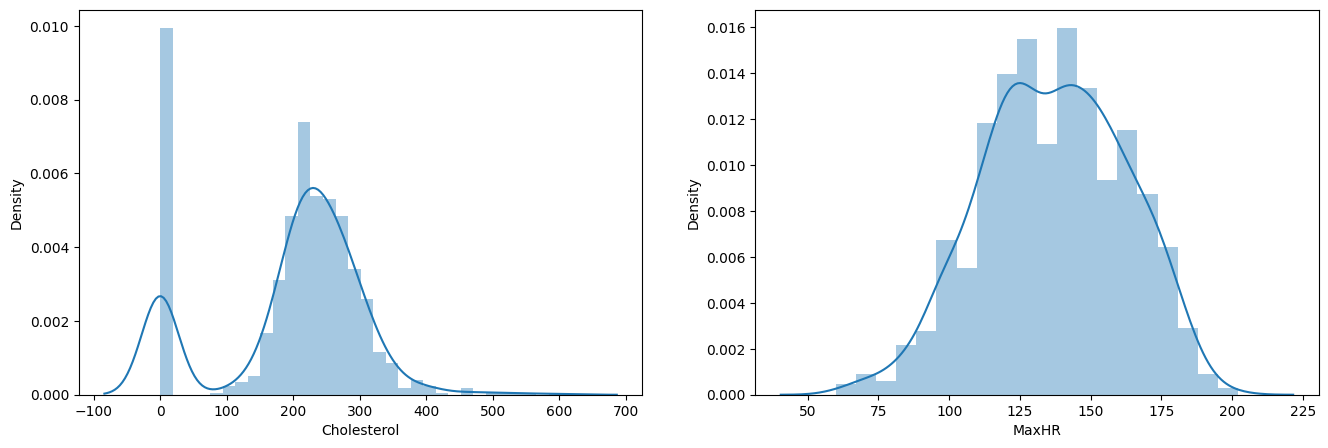

In [ ]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['Cholesterol'])

plt.subplot(1,2,2)
sns.distplot(df['MaxHR'])

plt.show()

/tmp/ipython-input-996/4236633704.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Oldpeak'])


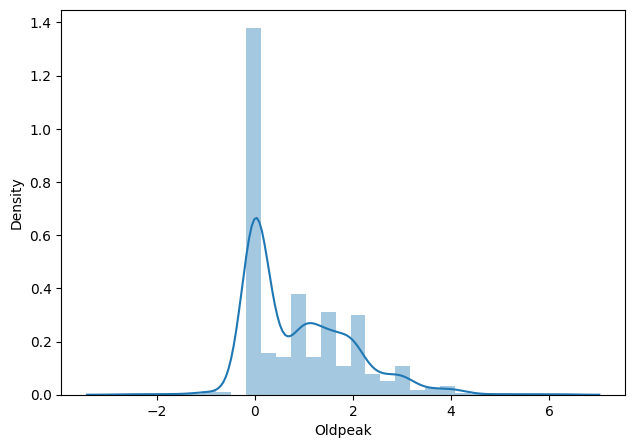

In [ ]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['Oldpeak'])

plt.show()

/tmp/ipython-input-996/1994904417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['RestingBP'])
/tmp/ipython-input-996/1994904417.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Cholesterol'])


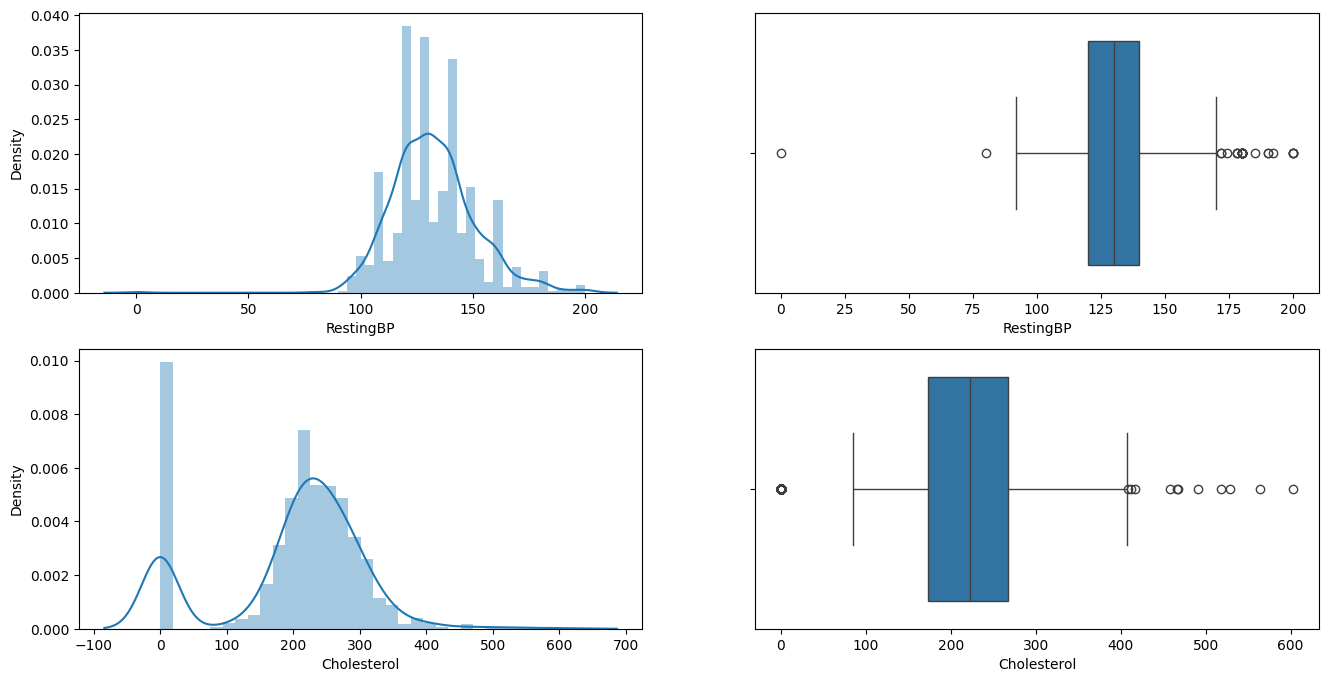

In [ ]:
#comparision
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['RestingBP'])

plt.subplot(2,2,2)
sns.boxplot(x=df['RestingBP'])

plt.subplot(2,2,3)
sns.distplot(df['Cholesterol'])

plt.subplot(2,2,4)
sns.boxplot(x=df['Cholesterol'])


plt.show()

/tmp/ipython-input-996/2052300868.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Oldpeak'])


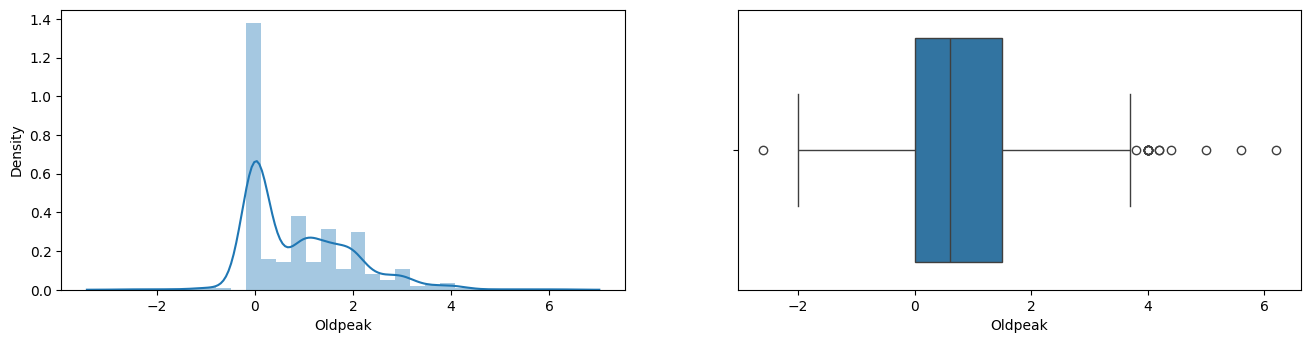

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['Oldpeak'])

plt.subplot(2,2,2)
sns.boxplot(x=df['Oldpeak'])

plt.show()

<Axes: xlabel='Sex', ylabel='HeartDisease'>

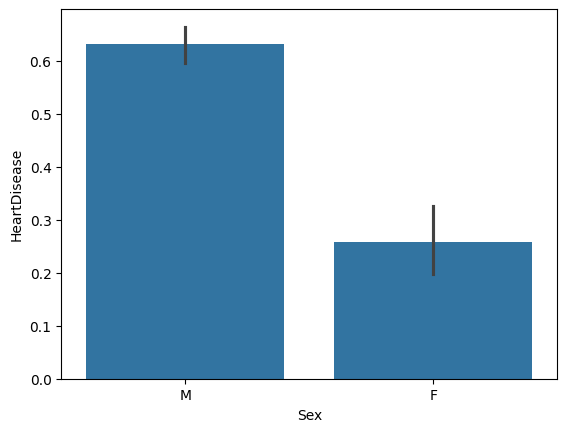

In [ ]:
#check catergorial features relation target feature
sns.barplot(x=df['Sex'],y=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='HeartDisease'>

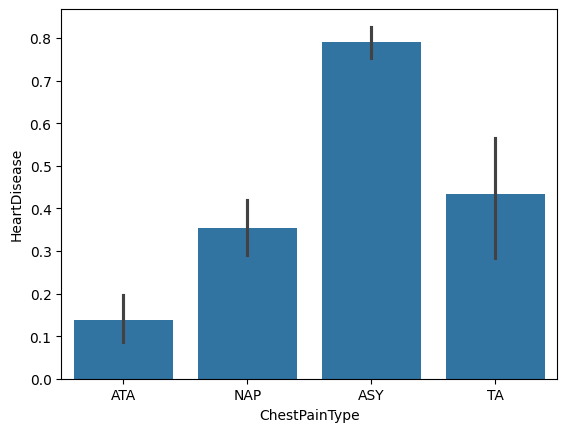

In [ ]:
sns.barplot(x=df['ChestPainType'],y=df['HeartDisease'])

<Axes: xlabel='RestingECG', ylabel='HeartDisease'>

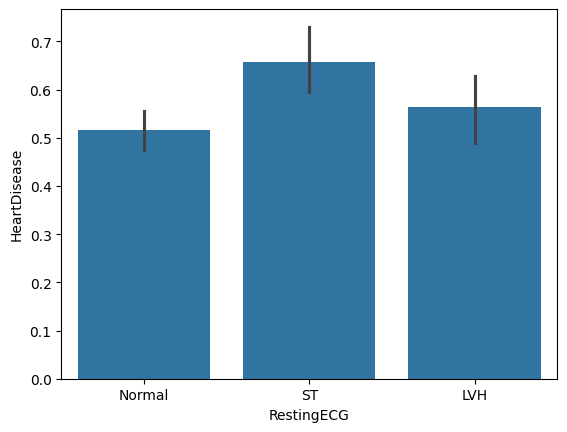

In [ ]:
sns.barplot(x=df['RestingECG'],y=df['HeartDisease'])

<Axes: xlabel='ExerciseAngina', ylabel='HeartDisease'>

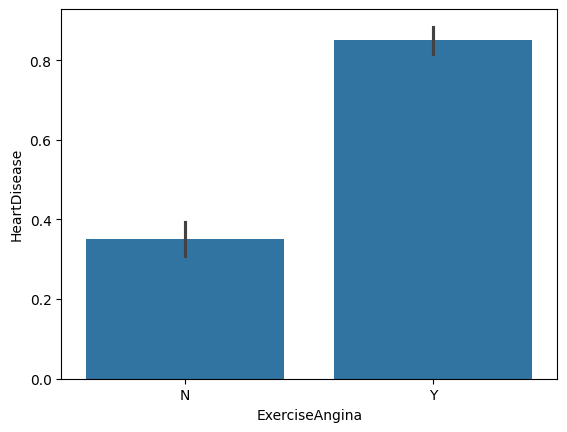

In [ ]:
sns.barplot(x=df['ExerciseAngina'],y=df['HeartDisease'])

<Axes: xlabel='ST_Slope', ylabel='HeartDisease'>

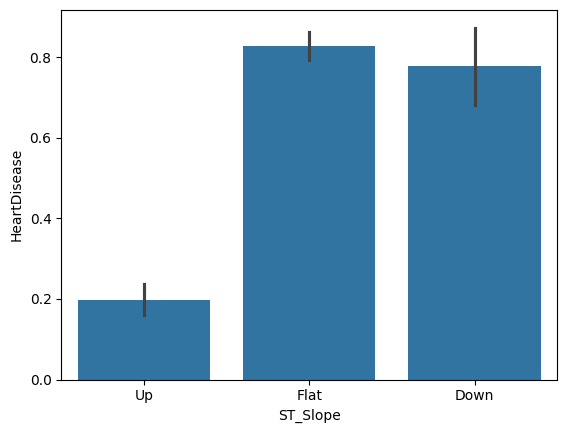

In [ ]:
sns.barplot(x=df['ST_Slope'],y=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='HeartDisease'>

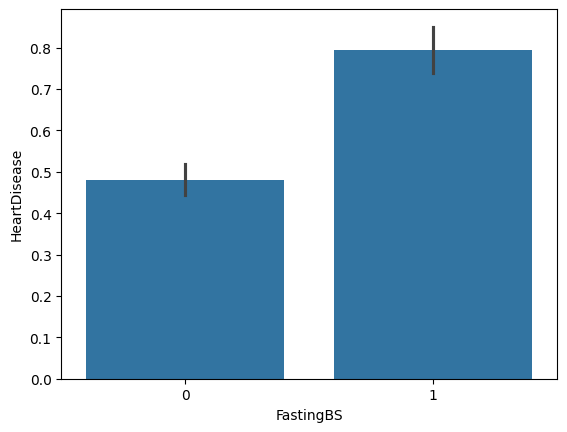

In [ ]:
sns.barplot(x=df['FastingBS'],y=df['HeartDisease'])

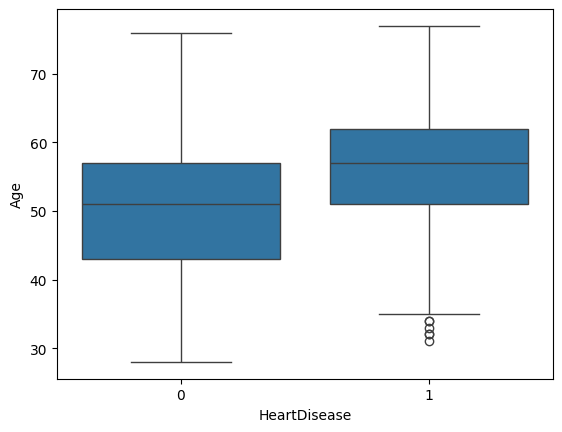

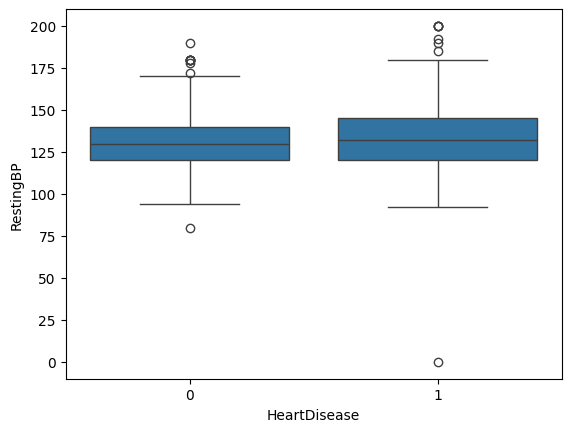

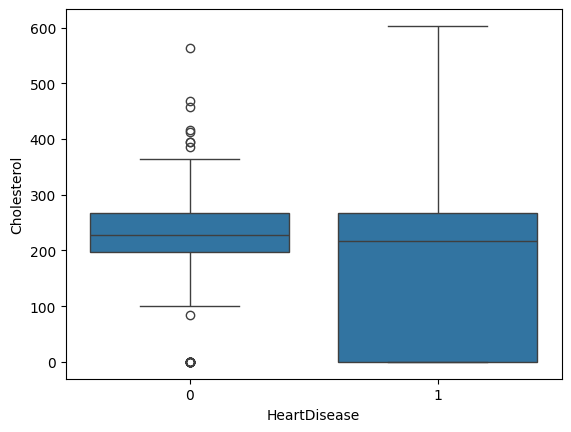

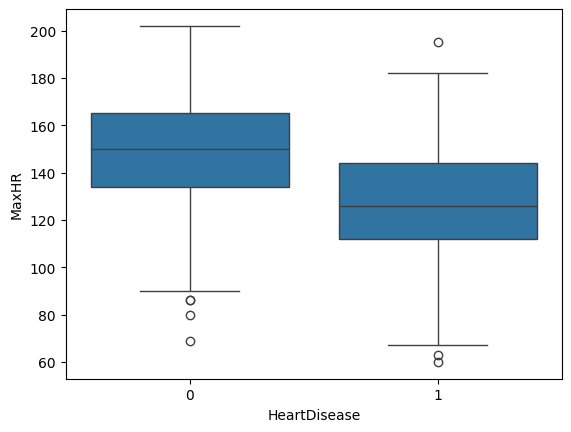

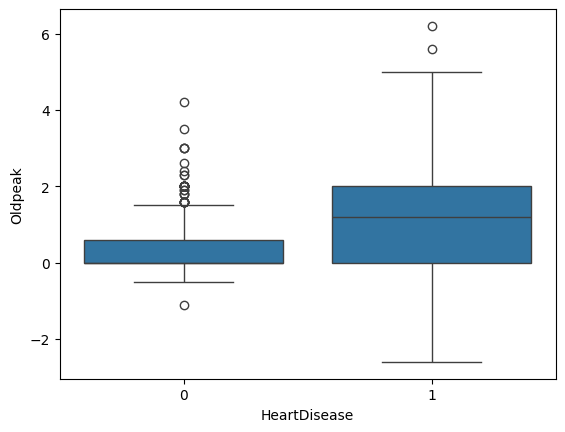

In [ ]:
numerical = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
for col in numerical:
    sns.boxplot(x=df['HeartDisease'],y=df[col])
    plt.show()

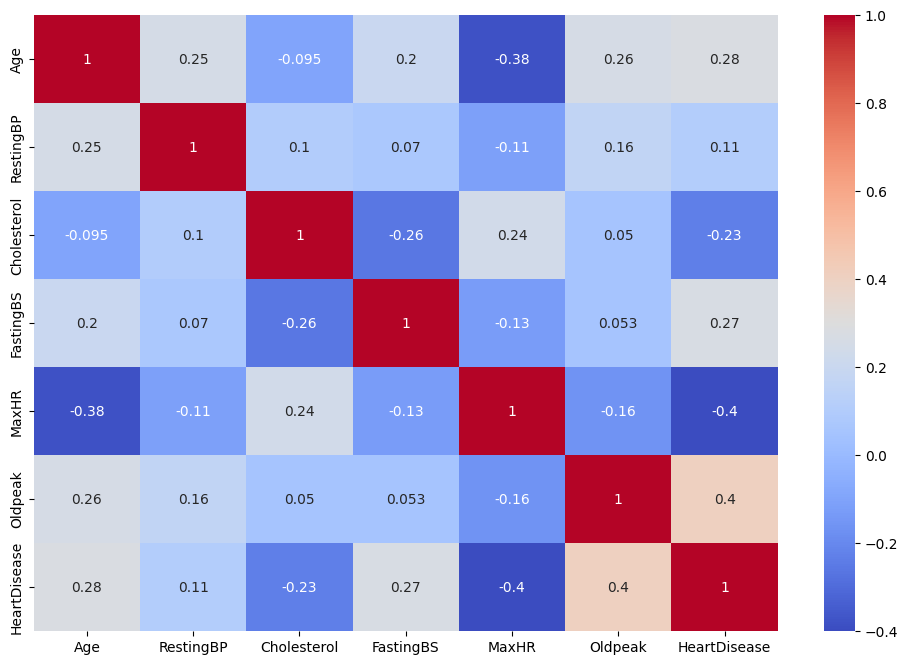

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True, cmap='coolwarm')
plt.show()

## DATA PREPROCCING

In [ ]:
percentile_25 = df[['RestingBP','Cholesterol']].quantile(0.25)
percentile_75 = df[['RestingBP','Cholesterol']].quantile(0.75)

In [ ]:
percentile_25

,0.25
RestingBP,120.00
Cholesterol,173.25


In [ ]:
iqr = percentile_75 - percentile_25

In [ ]:
iqr

,0
RestingBP,20.00
Cholesterol,93.75


In [ ]:
upper_limit = percentile_75 + 1.5 * iqr
lower_limit = percentile_25 - 1.5 * iqr

In [ ]:
print('upper limit', upper_limit)
print('lower limit', lower_limit)

upper limit RestingBP      170.000
Cholesterol    407.625
dtype: float64
lower limit RestingBP      90.000
Cholesterol    32.625
dtype: float64


In [ ]:
df_cap = df.copy()
df_cap['RestingBP'] = np.where(
    df_cap['RestingBP'] > upper_limit['RestingBP'],
    upper_limit['RestingBP'],
    np.where(df_cap['RestingBP'] < lower_limit['RestingBP'],
             lower_limit['RestingBP'],
             df_cap['RestingBP']
            )
)

df_cap['Cholesterol'] = np.where(
    df_cap['Cholesterol'] > upper_limit['Cholesterol'],
    upper_limit['Cholesterol'],
    df_cap['Cholesterol']
)

In [ ]:
df_cap.shape

(918, 12)

## Model Selecting

In [ ]:
df = df_cap.copy()

In [ ]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

In [ ]:
numeric_features = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
categorical_features = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

In [ ]:
preprocessor = make_column_transformer(
    (StandardScaler(),numeric_features),
    (OneHotEncoder(drop="first", sparse_output=False),categorical_features)
)

In [ ]:
pipeline = make_pipeline(
    preprocessor,
    LogisticRegression()
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("accuracy", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy 0.8315217391304348
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        77
           1       0.90      0.80      0.85       107

    accuracy                           0.83       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.83      0.83       184

